# Encoding techniques and quantum classification

## State reachability, kernel geometry, separator expressivity, and empirical trainability

In this lecture we hold the dataset and downstream learning algorithms fixed while changing the quantum feature map.

We will distinguish three related ideas:

1. **State reachability:** Which quantum states can be produced as the data point varies?
2. **Separator expressivity:** Which decision functions become accessible after the encoded states are processed?
3. **Empirical trainability:** Can a derivative-free optimizer find useful variational parameters reliably?

The objective is to expose how encoding changes the learning problem, no advantage claims here!

In [1]:
# %pip install -q \
#     "qiskit==2.5.2" \
#     "qiskit-machine-learning==0.9.1" \
#     "kagglehub>=0.3" \
#     "scikit-learn>=1.6" \
#     "pandas>=2.2" \
#     "matplotlib>=3.9" \
#     "seaborn>=0.13" \
#     "pylatexenc>=2.10"

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import efficient_su2, zz_feature_map

from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.primitives import QMLSampler
from qiskit_machine_learning.utils import algorithm_globals

from qml_encoding_utils import (
    kernel_diagnostics,
    plot_classifier_grid,
    plot_decision_spectra,
    plot_kernel_geometry,
    plot_kernel_matrices,
    plot_loss_histories,
    plot_vqc_boundaries,
    separator_diagnostics,
)

sns.set_theme(style="whitegrid", context="notebook")

SEED = 17
rng = np.random.default_rng(SEED)
algorithm_globals.random_seed = SEED

/Users/tchatterjee/Workspace/python/qml592/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The common classification task

We use the Iris dataset downloaded from Kaggle (you can also use the scikit-learn version of the dataset). To keep the effect of quantum encoding directly observable, we restrict the problem to
- `Iris-versicolor`;
- `Iris-virginica`.

We use two input features:
- petal length;
- petal width.

We deliberately exclude `Iris-setosa` because it is nearly trivially separable from the other species using petal measurements. The Versicolor--Virginica problem has a visible but imperfect class boundary, making information loss, periodicity, kernel geometry, and variational optimization easier to compare. The physical measurements will first be mapped into the unit square. Every encoding then receives the same scaled input

$$
u=(u_{\mathrm{length}},u_{\mathrm{width}})\in[0,1]^2.
$$

In [3]:
# Setup the dataset
dataset_directory = Path(kagglehub.dataset_download("uciml/iris"))
csv_files = sorted(dataset_directory.glob("*.csv"))
dataset_path = csv_files[0]
iris = pd.read_csv(dataset_path)

# Display the dataset
display(iris.head())
display(iris.columns.to_series(name="column"))

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Id                          Id
SepalLengthCm    SepalLengthCm
SepalWidthCm      SepalWidthCm
PetalLengthCm    PetalLengthCm
PetalWidthCm      PetalWidthCm
Species                Species
Name: column, dtype: str

In [4]:
# We will only look at these columns
required_columns = ["PetalLengthCm", "PetalWidthCm", "Species"]

# Now set the labels what is 0 and what is 1
species_to_label = {
    "Iris-versicolor": 0,
    "Iris-virginica": 1,
}

# Locate the "Species" column and select only the versicolor and the virginica species in there
# drop everything else
data = iris.loc[iris["Species"].isin(species_to_label), required_columns].dropna()

# Now assign them the labels and drop everything else
data["label"] = data["Species"].map(species_to_label)
data = data.reset_index(drop=True)

# Display the new cleaned dataset
display(data.head())
display(data["Species"].value_counts())

,PetalLengthCm,PetalWidthCm,Species,label
0,4.7,1.4,Iris-versicolor,0
1,4.5,1.5,Iris-versicolor,0
2,4.9,1.5,Iris-versicolor,0
3,4.0,1.3,Iris-versicolor,0
4,4.6,1.5,Iris-versicolor,0


Species
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Visualize how they look like in a scatterplot

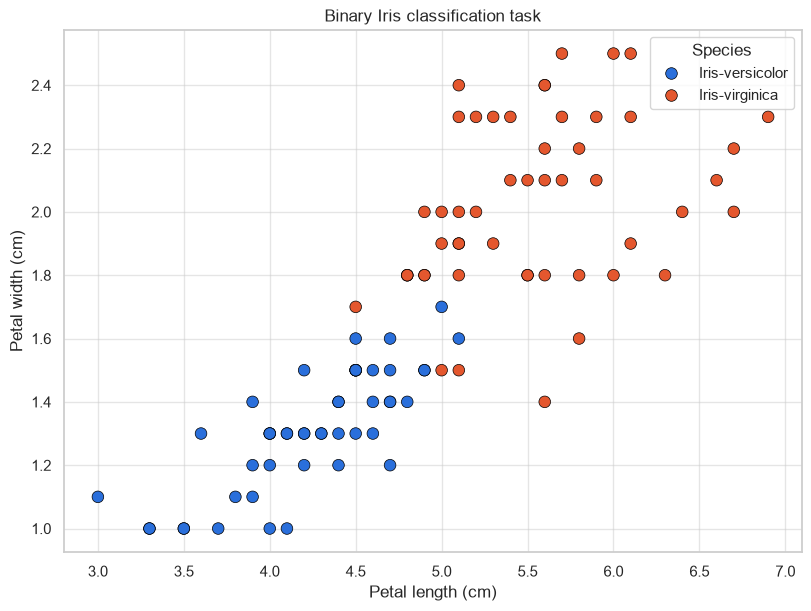

In [5]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.scatterplot(
    data=data,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    palette={
        "Iris-versicolor": "#2A6FDB",
        "Iris-virginica": "#E4572E",
    },
    edgecolor="black",
    linewidth=0.5,
    s=70,
    ax=ax,
)

ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Binary Iris classification task")

plt.show()

### Split into training and testing

There should be about 75 training observations after the split, so we do not need to reduce the dataset aggressively.

In [6]:
# Features
X = data[["PetalLengthCm", "PetalWidthCm"]].to_numpy()
y = data["label"].to_numpy()

# The actual split
# The stratify=y thing specifies that data is split in a stratified fashion, using this as the class labels
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y,random_state=SEED)

# Initialize a scalar to scale data and normalize its values
input_scaler = MinMaxScaler()
X_train_unit = input_scaler.fit_transform(X_train_raw)
X_test_unit = input_scaler.transform(X_test_raw)

print("Training shape:", X_train_unit.shape)
print("Test shape:", X_test_unit.shape)
print("Class counts in training set:", np.bincount(y_train))
print("Class counts in test set:", np.bincount(y_test))

Training shape: (75, 2)
Test shape: (25, 2)
Class counts in training set: [38 37]
Class counts in test set: [12 13]


In [7]:
quantum_training_frame = pd.DataFrame(
    {
        "scaled_petal_length": X_train_unit[:, 0],
        "scaled_petal_width": X_train_unit[:, 1],
        "label": y_train,
    }
)

# Just making sure this is balanced
N_PER_CLASS = 35

grouped_data = quantum_training_frame.groupby("label", group_keys=False)
quantum_training_frame = grouped_data.sample(n=N_PER_CLASS, random_state=SEED)
quantum_training_frame = quantum_training_frame.sample(frac=1.0, random_state=SEED,)

quantum_training_frame = quantum_training_frame.reset_index(drop=True)

# Specify the dataset to quantum
X_train_quantum = quantum_training_frame[["scaled_petal_length", "scaled_petal_width"]].to_numpy()
y_train_quantum = quantum_training_frame["label"].to_numpy()

print("Quantum training shape:", X_train_quantum.shape)
display(quantum_training_frame["label"].value_counts())

Quantum training shape: (70, 2)


label
1    35
0    35
Name: count, dtype: int64

## What exactly are we studying?

A quantum machine-learning model contains several conceptually different layers. In this notebook, we study three of them:

- the quantum states produced by an encoding;
- the similarity measure induced by those states;
- the classification functions produced after adding a trainable circuit.

These objects are related, but they are not interchangeable.

### The states reached by the encoding

We begin with a classical data point $x\in\mathcal{X}$. An encoding circuit $U_\phi(x)$ maps this point to a quantum state:

$$
|\phi(x)\rangle
=
U_\phi(x)|0\rangle^{\otimes n}.
$$

As $x$ varies over the input space, the circuit produces a collection of quantum states:

$$
\mathcal{M}_\phi
=
\left\{
|\phi(x)\rangle
:
x\in\mathcal{X}
\right\}.
$$

We call $\mathcal{M}_\phi$ the reachable state set of the encoding.

The full state space of $n$ qubits has dimension $2^n$, but this does not mean that the data can reach every state in that space. The data may trace out only a curve, a surface, a finite collection of basis states, or some other restricted subset.

This is the first question we study:

> As the classical data vary, which quantum states can the encoding actually reach?

Different encodings answer this question differently. Basis encoding reaches a discrete collection of computational-basis states. Angle encoding produces a continuous family of product states. Dense-angle encoding wraps a two-dimensional input space around a single Bloch sphere. An entangling feature map can reach states that cannot be written as products of individual qubit states.

### The similarity geometry created by the encoding

After encoding two inputs $x$ and $z$, we can compare their quantum states using their fidelity:

$$
K_\phi(x,z)
=
\left|
\langle\phi(x)|\phi(z)\rangle
\right|^2.
$$

This quantity is the fidelity quantum kernel.

It answers a different question:

> According to the encoding, how similar are two classical data points?

The encoding therefore imposes a new geometry on the dataset. Two points that are close in the original feature space need not remain close after encoding. Conversely, two distinct inputs may be mapped to the same quantum state and become indistinguishable.

To see why this is a kernel, define the density operator

$$
\rho_\phi(x)
=
|\phi(x)\rangle\langle\phi(x)|.
$$

The fidelity can then be written as

$$
K_\phi(x,z)
=
\operatorname{Tr}
\left[
\rho_\phi(x)\rho_\phi(z)
\right].
$$

Thus, the quantum kernel is an inner product between encoded density operators. The classifier does not operate directly on the original coordinates. It operates on the similarity geometry created by the encoding.

In this notebook, we inspect that geometry using kernel matrices, kernel eigenvalues, class alignment, effective rank, and distances between encoded states.

### The classification functions available to the model

Encoding the data does not by itself produce a classifier. We must still process the encoded state and measure an output.

For a variational quantum classifier, we apply a trainable circuit $V(\theta)$ after the encoding:

$$
|\psi(x,\theta)\rangle
=
V(\theta)U_\phi(x)|0\rangle^{\otimes n}.
$$

A measurement then produces a real-valued classification score $f_\theta(x)$. For a binary classifier, we may define

$$
f_\theta(x)
=
p_\theta(1\mid x)
-
p_\theta(0\mid x).
$$

The predicted class changes where

$$
f_\theta(x)=0.
$$

As the trainable parameters $\theta$ vary, the model can generate a family of decision functions:

$$
\mathcal{F}_{\phi,V}
=
\left\{
f_\theta(x)
:
\theta\in\Theta
\right\}.
$$

This is the reachable function family of the variational model.

It depends on both parts of the circuit:

$$
\text{reachable functions}
=
\text{encoding}
+
\text{trainable ansatz}
+
\text{measurement}.
$$

The encoding determines how the classical variables enter the circuit. The ansatz determines how those encoded states can subsequently be transformed. The measurement determines which information is converted into a class score.

This leads to the third question we study:

> Given an encoding and a fixed trainable circuit, which decision boundaries can the classifier represent?

### The distinction we will maintain

The logical flow of the notebook is therefore

$$
x
\longmapsto
|\phi(x)\rangle
\longmapsto
K_\phi(x,z)
\longmapsto
f(x).
$$

The reachable quantum states describe where the encoding sends the data.

The quantum kernel describes the similarity geometry among those states.

The decision function describes how a learning algorithm uses that geometry to separate the classes.

A feature map may reach many distinguishable states without arranging them according to the labels. A kernel may have a large effective rank without producing a useful separator. A useful family of decision functions may exist even though a variational optimizer fails to find one.

For this reason, we will examine state reachability, kernel geometry, separator expressivity, and empirical trainability separately.

## Encoding transformations used in this experiment

Let

$$
u
=
\left(
u_{\mathrm{length}},
u_{\mathrm{width}}
\right)
\in[0,1]^2
$$

denote the scaled petal length and petal width of an Iris flower.

The same scaled input $u$ is supplied to every encoding. Each encoding then transforms these two numbers into circuit parameters or quantum-state amplitudes in a different way.

| Encoding | Transformation of the Iris features | Qubits | Main information effect |
|---|---|---:|---|
| Basis | Place each petal feature into one of three bins and write the bin index using two bits | 4 | Replaces continuous measurements with discrete categories |
| Amplitude | Normalize the padded vector $(1,u_{\mathrm{length}},u_{\mathrm{width}},0)$ | 2 | Represents both petal measurements through relative amplitudes |
| Angle | $(\pi u_{\mathrm{length}},\pi u_{\mathrm{width}})$ | 2 | Maps each petal feature to a separate qubit rotation |
| Phase | $(2\pi u_{\mathrm{length}},2\pi u_{\mathrm{width}})$ | 2 | Maps each feature to a periodic phase |
| Dense angle | $(\pi u_{\mathrm{length}},2\pi u_{\mathrm{width}})$ | 1 | Places both petal features on one Bloch sphere |
| $ZZ$ | $(\pi u_{\mathrm{length}},\pi u_{\mathrm{width}})$ | 2 | Adds a joint, nonlinear dependence on petal length and width |



### Basis encoding

Each continuous petal measurement is first assigned to one of three bins:
$$
0,\qquad 1,\qquad 2.
$$

The bin index is then represented by two classical bits:
$$
0\longmapsto 00,
\qquad
1\longmapsto 01,
\qquad
2\longmapsto 10.
$$
Since we use two petal features, the complete encoded bit string contains four bits and therefore requires four qubits. The basis encoding deliberately discards information within each bin. Two flowers with different petal measurements prepare exactly the same quantum state whenever both measurements fall into the same pair of bins.

In [27]:
def basis_coordinates(X:np.ndarray, bins: int, return_intermediates:bool=False):
    """Convert scaled Iris measurements into basis-encoding coordinates.

    Each flower is represented by its scaled petal length and petal width.
    Each feature is assigned to one of four bins, and each bin index is
    represented using two bits. The final encoding therefore contains four
    bits per flower.

    Args:
        X: Input data with shape ``(n_samples, 2)`` or ``(2,)``. Each row
            must contain scaled petal length followed by scaled petal width.
            All values must lie in the interval ``[0, 1]``.
        return_intermediates: Whether to return the intermediate binning and
            bit-extraction results in addition to the encoded coordinates.

    Returns:
        If ``return_intermediates`` is ``False``, returns a floating-point
        array with shape ``(n_samples, 4)`` containing

        ``[length high bit, length low bit, width high bit, width low bit]``.

        If ``return_intermediates`` is ``True``, returns a tuple containing
        the encoded array and a dictionary of intermediate arrays.

    Raises:
        ValueError: If the input does not contain exactly two features.
        ValueError: If any input value lies outside the interval ``[0, 1]``.
    """
    # Convert the input into a floating-point NumPy array.
    input_coordinates = np.asarray(X, dtype=float)

    # Convert one flower from shape (2,) into shape (1, 2).
    # This is done for demo purposes only. Ignore otherwise
    input_coordinates = np.atleast_2d(input_coordinates)

    # Map each feature from [0, 1] into [0, 4].
    scaled_bin_positions = bins * input_coordinates

    # Use the integer part to obtain the preliminary bin index.
    preliminary_bin_indices = np.floor(scaled_bin_positions).astype(int)

    # Map the endpoint x = 1 from index 4 back to the final valid bin.
    bin_indices = np.clip(preliminary_bin_indices, 0, bins - 1)

    # Separate the bin indices for the two Iris features.
    petal_length_bins = bin_indices[:, 0]
    petal_width_bins = bin_indices[:, 1]

    # Extract the two binary digits of the petal-length bin.
    petal_length_high_bit = (petal_length_bins >> 1) & 1
    petal_length_low_bit = petal_length_bins & 1

    # Extract the two binary digits of the petal-width bin.
    petal_width_high_bit = (petal_width_bins >> 1) & 1
    petal_width_low_bit = petal_width_bins & 1

    # Group the two bits associated with petal length.
    petal_length_bits = np.column_stack(
        [
            petal_length_high_bit,
            petal_length_low_bit,
        ]
    )

    # Group the two bits associated with petal width.
    petal_width_bits = np.column_stack(
        [
            petal_width_high_bit,
            petal_width_low_bit,
        ]
    )

    # Combine both two-bit encodings into one four-bit vector.
    encoded_bits = np.column_stack(
        [
            petal_length_bits,
            petal_width_bits,
        ]
    ).astype(float)

    # Return only the encoded array during ordinary preprocessing.
    if not return_intermediates:
        return encoded_bits

    # Collect the intermediate values for demonstrations and debugging.
    intermediates = {
        "input_coordinates": input_coordinates,
        "scaled_bin_positions": scaled_bin_positions,
        "preliminary_bin_indices": preliminary_bin_indices,
        "bin_indices": bin_indices,
        "petal_length_bins": petal_length_bins,
        "petal_width_bins": petal_width_bins,
        "petal_length_bits": petal_length_bits,
        "petal_width_bits": petal_width_bits,
    }

    return encoded_bits, intermediates

In [41]:
N_BASIS_BINS = 4
example_flower = [0.40, 0.80]
encoded_bits, basis_steps = basis_coordinates(example_flower, bins=N_BASIS_BINS, return_intermediates=True)
print("Scaled Iris features:", example_flower)
print("Basis coordinates:", example_bits)

Scaled Iris features: [0.4, 0.8]
Basis coordinates: [[0. 1. 1. 1.]]


In [42]:
print("Original scaled input")
print(steps["input_coordinates"])

print("\nPositions after multiplying by four")
print(steps["scaled_bin_positions"])

print("\nPreliminary bin indices obtained with floor")
print(steps["preliminary_bin_indices"])

print("\nFinal bin indices after clipping")
print(steps["bin_indices"])

print("\nPetal-length bits")
print(steps["petal_length_bits"])

print("\nPetal-width bits")
print(steps["petal_width_bits"])

print("\nComplete four-bit encoding")
print(encoded_bits)

Original scaled input
[[0.4 0.8]]

Positions after multiplying by four
[[1.6 3.2]]

Preliminary bin indices obtained with floor
[[1 3]]

Final bin indices after clipping
[[1 3]]

Petal-length bits
[[0 1]]

Petal-width bits
[[1 1]]

Complete four-bit encoding
[[0. 1. 1. 1.]]


## From an Iris flower to a computational-basis state

Consider a flower with scaled petal measurements

$$
u
=
\left(
u_{\mathrm{length}},
u_{\mathrm{width}}
\right)
=
(0.40,0.80).
$$

Each coordinate is placed into one of four bins using

$$
q(u)
=
\min
\left(
\left\lfloor4u\right\rfloor,
3
\right).
$$

For petal length,

$$
q(0.40)
=
\left\lfloor1.60\right\rfloor
=
1
=
01_2.
$$

For petal width,

$$
q(0.80)
=
\left\lfloor3.20\right\rfloor
=
3
=
11_2.
$$

Combining the two binary representations gives

$$
b(u)
=
(0,1,1,1).
$$

The encoded quantum state is therefore

$$
|\phi_{\mathrm{basis}}(u)\rangle
=
|0111\rangle.
$$

The important operation is quantization. Every flower in the same two-dimensional bin is mapped to the same computational-basis state. Basis encoding therefore preserves the identity of the bin but discards every distinction between flowers inside that bin.

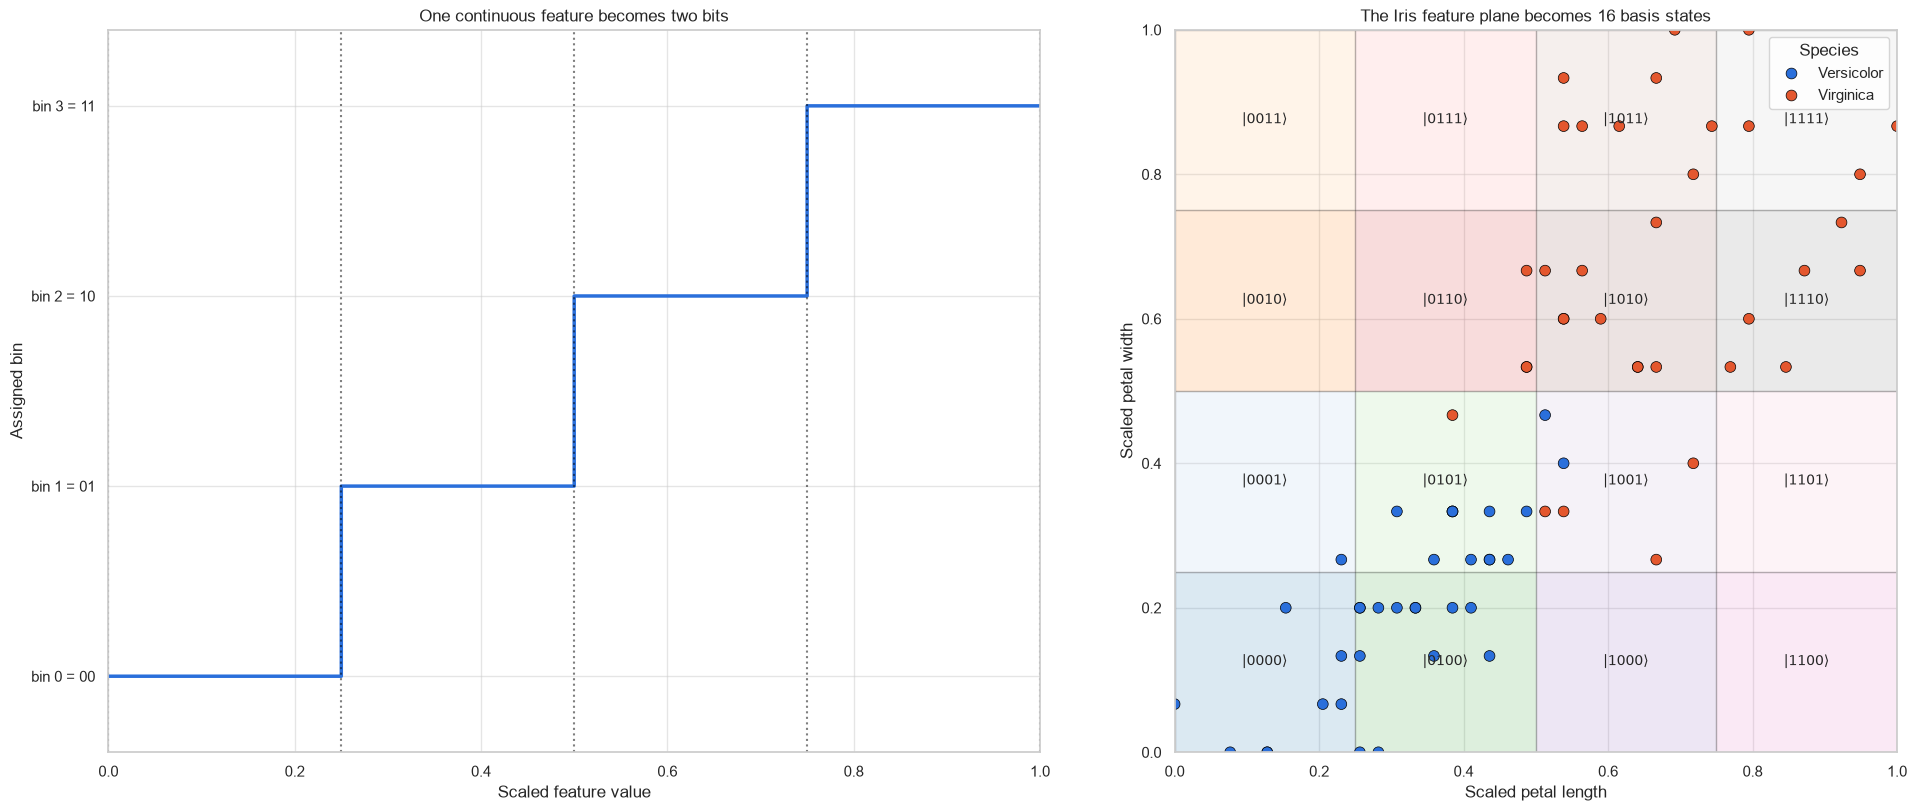

In [48]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# LEFT PANEL
feature_values = np.linspace(0.0, 1.0, 1001)
one_dimensional_bins = np.floor(N_BASIS_BINS * feature_values).astype(int)
one_dimensional_bins = np.clip(one_dimensional_bins, 0, N_BASIS_BINS - 1)

axes[0].step(feature_values, one_dimensional_bins, where="post", linewidth=2.5, color="#2A6FDB")
for boundary in np.linspace(0, 1, N_BASIS_BINS + 1):
    axes[0].axvline(boundary, color="black", linestyle=":", alpha=0.5)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-0.4, 3.4)
axes[0].set_yticks(
    [0, 1, 2, 3],
    [
        "bin 0 = 00",
        "bin 1 = 01",
        "bin 2 = 10",
        "bin 3 = 11",
    ],
)
axes[0].set_xlabel("Scaled feature value")
axes[0].set_ylabel("Assigned bin")
axes[0].set_title("One continuous feature becomes two bits")

# Right panel: quantization of the complete Iris feature plane.
cell_width = 1.0 / N_BASIS_BINS
cell_colors = plt.get_cmap("tab20").colors

for length_bin in range(N_BASIS_BINS):
    for width_bin in range(N_BASIS_BINS):
        lower_length = length_bin * cell_width
        lower_width = width_bin * cell_width

        cell_number = (
            N_BASIS_BINS * length_bin
            + width_bin
        )

        rectangle = Rectangle(
            (lower_length, lower_width),
            cell_width,
            cell_width,
            facecolor=cell_colors[cell_number],
            edgecolor="black",
            linewidth=1.0,
            alpha=0.16,
        )

        axes[1].add_patch(rectangle)

        length_center = lower_length + cell_width / 2
        width_center = lower_width + cell_width / 2

        cell_bits = basis_coordinates(
            [length_center, width_center], bins=N_BASIS_BINS,
        )[0].astype(int)

        bit_string = "".join(
            cell_bits.astype(str)
        )

        axes[1].text(
            length_center,
            width_center,
            rf"$|{bit_string}\rangle$",
            ha="center",
            va="center",
            fontsize=10,
        )

sns.scatterplot(
    x=X_train_quantum[:, 0],
    y=X_train_quantum[:, 1],
    hue=y_train_quantum,
    palette={
        0: "#2A6FDB",
        1: "#E4572E",
    },
    edgecolor="black",
    linewidth=0.5,
    s=60,
    ax=axes[1],
)

axes[1].set_xlim(0.0, 1.0)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_aspect("equal")

axes[1].set_xlabel("Scaled petal length")
axes[1].set_ylabel("Scaled petal width")
axes[1].set_title("The Iris feature plane becomes 16 basis states")

handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles=handles,
    labels=["Versicolor", "Virginica"],
    title="Species",
)

plt.show()


## Amplitude Encoding

The two scaled measurements are augmented and padded to form

$$
a(u)
=
\left(
1,
u_{\mathrm{length}},
u_{\mathrm{width}},
0
\right).
$$

The vector is normalized before it is loaded into the amplitudes:

$$
|\phi_{\mathrm{amp}}(u)\rangle
=
\frac{
|00\rangle
+
u_{\mathrm{length}}|01\rangle
+
u_{\mathrm{width}}|10\rangle
}{
\sqrt{
1+
u_{\mathrm{length}}^2+
u_{\mathrm{width}}^2
}
}.
$$

The constant component prevents normalization from erasing all information about the magnitude of the original two-dimensional vector. The final zero pads the vector to dimension four so that it can be represented by two qubits.


In [56]:
def amplitude_coordinates(X, return_intermediates=False):
    """Construct normalized amplitude vectors from Iris measurements.

    The scaled petal measurements are embedded into the four-dimensional
    vector ``(1, petal length, petal width, 0)``. Each vector is then
    normalized to have unit Euclidean norm.

    Args:
        X: Input data with shape ``(n_samples, 2)`` or ``(2,)``. Each row
            contains scaled petal length followed by scaled petal width.
        return_intermediates: Whether to return the intermediate augmented
            vectors, norms, amplitudes, and probabilities.

    Returns:
        If ``return_intermediates`` is ``False``, returns the normalized
        amplitude vectors with shape ``(n_samples, 4)``.

        If ``return_intermediates`` is ``True``, returns a tuple containing
        the normalized amplitude vectors and a dictionary of intermediate
        arrays.

    Raises:
        ValueError: If the input does not contain exactly two features.
        ValueError: If any input value lies outside the interval ``[0, 1]``.
    """
    # Convert the input into a floating-point NumPy array.
    input_coordinates = np.asarray(X, dtype=float)

    # Convert one flower from shape (2,) into shape (1, 2) for the demo
    input_coordinates = np.atleast_2d(input_coordinates)


    # Add a constant coordinate and one padding coordinate.
    #
    # [petal length, petal width]
    # becomes
    # [1, petal length, petal width, 0].
    augmented_vectors = np.column_stack(
        [
            np.ones(len(input_coordinates)),
            input_coordinates[:, 0],
            input_coordinates[:, 1],
            np.zeros(len(input_coordinates)),
        ]
    )

    # Calculate the Euclidean norm of each augmented vector.
    vector_norms = np.linalg.norm(augmented_vectors, axis=1, keepdims=True)

    # Divide every vector by its norm so that its squared amplitudes sum to 1.
    normalized_amplitudes = augmented_vectors / vector_norms

    # Squaring the amplitudes gives computational-basis probabilities.
    basis_probabilities = np.abs(normalized_amplitudes) ** 2


    # Return only the amplitudes during normal preprocessing.
    if not return_intermediates:
        return normalized_amplitudes

    # Return the complete calculation for demonstrations.
    intermediates = {
        "input_coordinates": input_coordinates,
        "augmented_vectors": augmented_vectors,
        "vector_norms": vector_norms,
        "normalized_amplitudes": normalized_amplitudes,
        "basis_probabilities": basis_probabilities,
    }

    return normalized_amplitudes, intermediates

In [57]:
# Demoing this
example_flower = [0.40, 0.80]

encoded_amplitudes, amplitude_steps = amplitude_coordinates(example_flower, return_intermediates=True)
basis_states = [
    "|00>",
    "|01>",
    "|10>",
    "|11>",
]

print("Original scaled Iris measurements:")
print(amplitude_steps["input_coordinates"])
print("\nAugmented vector:")
print(amplitude_steps["augmented_vectors"])

print("\nEuclidean norm:")
print(amplitude_steps["vector_norms"])

print("\nNormalized amplitude vector:")
print(encoded_amplitudes)

print("\nSum of measurement probabilities:")
print(amplitude_steps["basis_probabilities"].sum(axis=1))



Original scaled Iris measurements:
[[0.4 0.8]]

Augmented vector:
[[1.  0.4 0.8 0. ]]

Euclidean norm:
[[1.34164079]]

Normalized amplitude vector:
[[0.74535599 0.2981424  0.59628479 0.        ]]

Sum of measurement probabilities:
[1.]


## How does the amplitude-coordinate transformation work?

Consider a flower with scaled petal measurements

$$
u
=
\left(
u_{\mathrm{length}},
u_{\mathrm{width}}
\right)
=
(0.40,0.80).
$$

### Constructing a four-dimensional vector

A two-qubit quantum state has four computational-basis states:

$$
|00\rangle,
\qquad
|01\rangle,
\qquad
|10\rangle,
\qquad
|11\rangle.
$$

It therefore has four amplitudes. We construct the classical vector

$$
a(u)
=
\left(
1,
u_{\mathrm{length}},
u_{\mathrm{width}},
0
\right).
$$

For this flower,

$$
a(u)
=
(1,0.40,0.80,0).
$$

The first coordinate is a constant bias coordinate. The final coordinate is padding that increases the vector dimension to four.

### Why normalization is required

A valid quantum state must satisfy

$$
\langle\psi|\psi\rangle=1.
$$

Equivalently, its amplitudes must obey

$$
\sum_j |\alpha_j|^2=1.
$$

The unnormalized Iris vector does not yet satisfy this condition. Its Euclidean norm is

$$
\|a(u)\|
=
\sqrt{
1^2
+
0.40^2
+
0.80^2
+
0^2
}.
$$

Therefore,

$$
\|a(u)\|
=
\sqrt{1.80}
\approx
1.3416.
$$

We divide every coordinate by this norm:

$$
\widetilde{a}(u)
=
\frac{a(u)}{\|a(u)\|}.
$$

Numerically,

$$
\widetilde{a}(u)
\approx
(0.7454,0.2981,0.5963,0).
$$

### Constructing the quantum state

The four normalized coordinates become the four computational-basis amplitudes:

$$
|\phi_{\mathrm{amp}}(u)\rangle
=
0.7454|00\rangle
+
0.2981|01\rangle
+
0.5963|10\rangle
+
0|11\rangle.
$$

More generally,

$$
|\phi_{\mathrm{amp}}(u)\rangle
=
\frac{
|00\rangle
+
u_{\mathrm{length}}|01\rangle
+
u_{\mathrm{width}}|10\rangle
}{
\sqrt{
1+
u_{\mathrm{length}}^2+
u_{\mathrm{width}}^2
}
}.
$$

The quantum state contains the petal measurements in its relative amplitudes.

### Measurement probabilities

Measuring the state in the computational basis does not return the amplitudes directly. It produces probabilities obtained by squaring their magnitudes:

$$
p_j
=
|\alpha_j|^2.
$$

For this example,

$$
p(00)
=
|0.7454|^2
\approx
0.5556,
$$

$$
p(01)
=
|0.2981|^2
\approx
0.0889,
$$

$$
p(10)
=
|0.5963|^2
\approx
0.3556,
$$

and

$$
p(11)=0.
$$

These probabilities satisfy

$$
p(00)+p(01)+p(10)+p(11)=1.
$$

Amplitude encoding does not mean that one measurement reveals the complete classical feature vector. The encoded information is distributed across the quantum amplitudes. Accessing that information requires repeated measurements or interference with another quantum state.

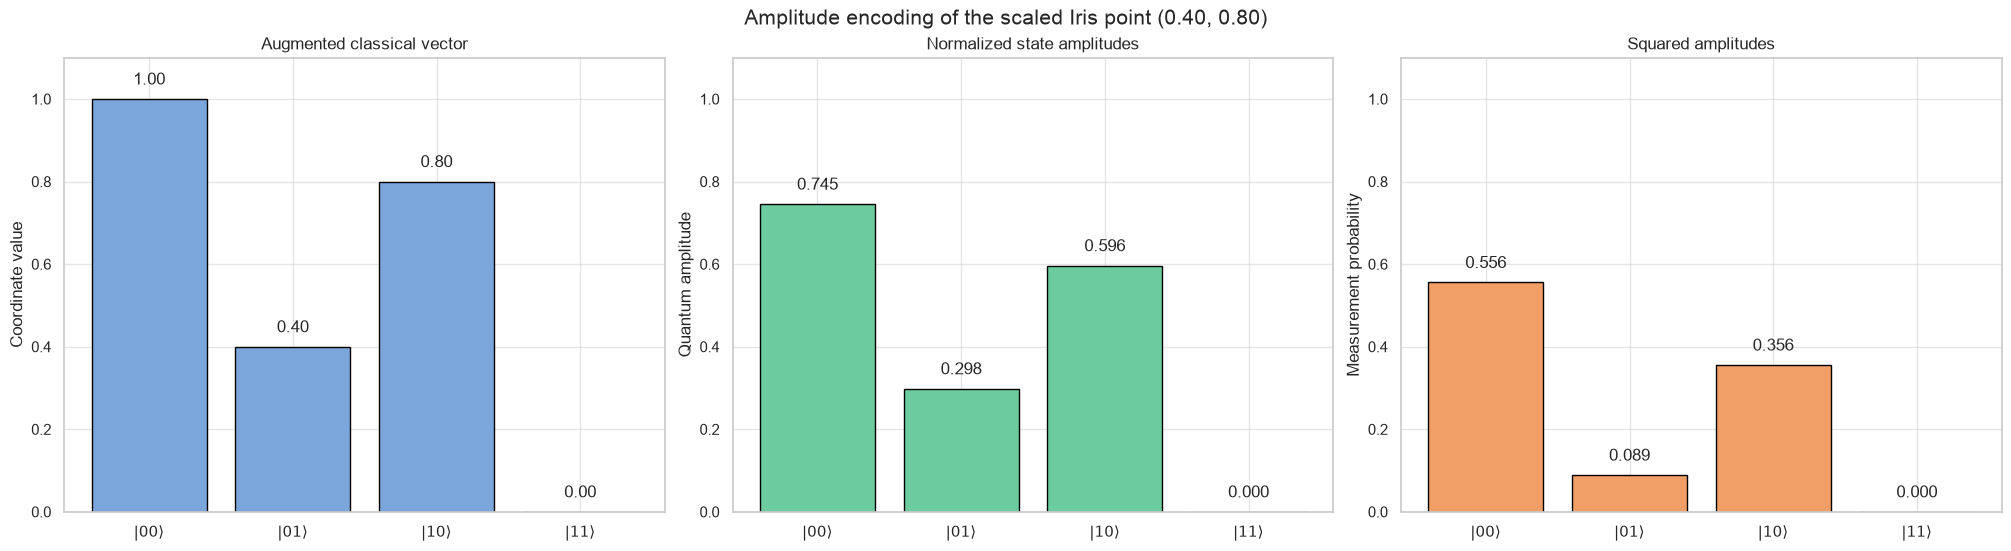

In [64]:
# This is all operating on the intermediates dict
augmented_vector = amplitude_steps["augmented_vectors"][0]
normalized_vector = amplitude_steps["normalized_amplitudes"][0]
measurement_probabilities = amplitude_steps["basis_probabilities"][0]

# Create basis labels for viz
basis_labels = [
    r"$|00\rangle$",
    r"$|01\rangle$",
    r"$|10\rangle$",
    r"$|11\rangle$",
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.4), constrained_layout=True)
# Unnormalized classical coordinates.
axes[0].bar(basis_labels, augmented_vector, color="#7AA6DC", edgecolor="black")
axes[0].set_ylim(0.0, 1.1)
axes[0].set_ylabel("Coordinate value")
axes[0].set_title("Augmented classical vector")

for index, value in enumerate(augmented_vector):
    axes[0].text(index, value + 0.035, f"{value:.2f}", ha="center")

# Normalized quantum amplitudes.
axes[1].bar(basis_labels, normalized_vector, color="#6CCB9F", edgecolor="black")
axes[1].set_ylim(0.0, 1.1)
axes[1].set_ylabel("Quantum amplitude")
axes[1].set_title("Normalized state amplitudes")

for index, value in enumerate(normalized_vector):
    axes[1].text(index, value + 0.035, f"{value:.3f}", ha="center")

# Computational-basis measurement probabilities.
axes[2].bar(basis_labels, measurement_probabilities, color="#F29E67", edgecolor="black")
axes[2].set_ylim(0.0, 1.1)
axes[2].set_ylabel("Measurement probability")
axes[2].set_title("Squared amplitudes")

for index, value in enumerate(measurement_probabilities):
    axes[2].text(index, value + 0.035, f"{value:.3f}", ha="center")

fig.suptitle(
    "Amplitude encoding of the scaled Iris point (0.40, 0.80)",
    fontsize=15,
)

plt.show()


## Preparing the amplitude-encoded state

The previous visualization calculated the desired amplitudes but did not construct a quantum circuit.

We now perform two demonstrations.

First, we construct a general amplitude-encoding routine that can encode an arbitrary real or complex vector. If the vector dimension is not a power of two, zeros are appended until it can be represented by an integer number of qubits.

Second, we apply the same routine to an actual flower from the Iris dataset. We decompose its state-preparation circuit into elementary gates and inspect the quantum state after each gate.

A general two-qubit state cannot be represented completely by one Bloch sphere. The Bloch sphere represents one qubit. For the two-qubit state, we therefore display:

- one Bloch sphere for each qubit's reduced state;
- a Q-sphere for the complete joint state.

In [66]:
import ipywidgets as widgets

from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import (
    DensityMatrix,
    Statevector,
    concurrence,
    partial_trace,
    purity,
)
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_qsphere,
)